<a href="https://colab.research.google.com/github/pradhapmoorthi/CVND/blob/Simple/0_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Nanodegree

## Project: Image Captioning

---

The Microsoft **C**ommon **O**bjects in **CO**ntext (MS COCO) dataset is a large-scale dataset for scene understanding.  The dataset is commonly used to train and benchmark object detection, segmentation, and captioning algorithms.  

![Sample Dog Output](https://github.com/pradhapmoorthi/CVND/blob/Simple/images/coco-examples.jpg?raw=1)

You can read more about the dataset on the [website](http://cocodataset.org/#home) or in the [research paper](https://arxiv.org/pdf/1405.0312.pdf).

In this notebook, you will explore this dataset, in preparation for the project.

## Step 1: Initialize the COCO API

We begin by initializing the [COCO API](https://github.com/cocodataset/cocoapi) that you will use to obtain the data.

In [1]:
import os

# Clean up previous temporary files and directories to ensure a fresh start
!rm -rf /tmp/annotations
!rm -f /tmp/annotations_trainval2014.zip

# Ensure the target directory for annotations exists before moving files
os.makedirs('/opt/cocoapi/annotations', exist_ok=True)

# Download the annotation zip file
!wget http://images.cocodataset.org/annotations/annotations_trainval2014.zip -O /tmp/annotations_trainval2014.zip

# Unzip the contents to /tmp/
!unzip /tmp/annotations_trainval2014.zip -d /tmp/

# Move the relevant files to the expected location
!mv /tmp/annotations/instances_val2014.json /opt/cocoapi/annotations/
!mv /tmp/annotations/captions_val2014.json /opt/cocoapi/annotations/

print("COCO val2014 annotation files downloaded and moved to /opt/cocoapi/annotations/")

--2026-02-18 01:08:11--  http://images.cocodataset.org/annotations/annotations_trainval2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.199.129, 3.5.27.189, 52.217.198.153, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.199.129|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252872794 (241M) [application/zip]
Saving to: ‘/tmp/annotations_trainval2014.zip’

/tmp/annotations_tr 100%[===================>] 241.16M  46.7MB/s    in 5.1s    

2026-02-18 01:08:16 (47.4 MB/s) - ‘/tmp/annotations_trainval2014.zip’ saved [252872794/252872794]

Archive:  /tmp/annotations_trainval2014.zip
  inflating: /tmp/annotations/instances_train2014.json  
  inflating: /tmp/annotations/instances_val2014.json  
  inflating: /tmp/annotations/person_keypoints_train2014.json  
  inflating: /tmp/annotations/person_keypoints_val2014.json  
  inflating: /tmp/annotations/captions_train2014.json  
  inflating: /tmp/annotations/captions_val2014

In [2]:
import os

# Define the directory where COCO API expects the data
dataDir = '/opt/cocoapi'
annotationsDir = os.path.join(dataDir, 'annotations')

# Create the directory if it doesn't exist
os.makedirs(annotationsDir, exist_ok=True)

print(f"Ensured directory exists: {annotationsDir}")

Ensured directory exists: /opt/cocoapi/annotations


In [3]:
import os
import sys
sys.path.append('/opt/cocoapi/PythonAPI')
from pycocotools.coco import COCO

# initialize COCO API for instance annotations
dataDir = '/opt/cocoapi'
dataType = 'val2014'
instances_annFile = os.path.join(dataDir, 'annotations/instances_{}.json'.format(dataType))
coco = COCO(instances_annFile)

# initialize COCO API for caption annotations
captions_annFile = os.path.join(dataDir, 'annotations/captions_{}.json'.format(dataType))
coco_caps = COCO(captions_annFile)

# get image ids
ids = list(coco.anns.keys())

loading annotations into memory...
Done (t=6.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.37s)
creating index...
index created!


First, let's create the necessary directory structure for the COCO dataset annotations.

Now, let's download the required annotation files for `val2014` dataset. We need `instances_val2014.json` for object instances and `captions_val2014.json` for image captions. These will be placed in the `annotations` subdirectory.

After executing the above cells, you can re-run the cell with the COCO API initialization to see if the `FileNotFoundError` is resolved.

## Step 2: Plot a Sample Image

Next, we plot a random image from the dataset, along with its five corresponding captions.  Each time you run the code cell below, a different image is selected.  

In the project, you will use this dataset to train your own model to generate captions from images!

http://images.cocodataset.org/val2014/COCO_val2014_000000553057.jpg


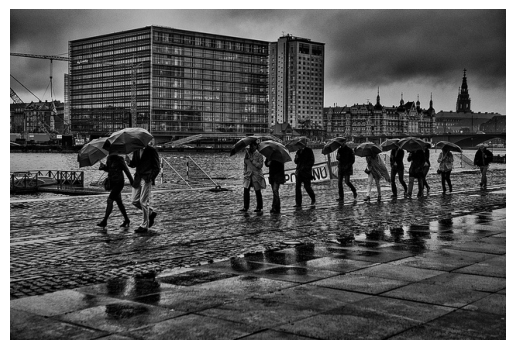

A group of people walking in the rain holding umbrellas.
Line of pedestrians walking in the rain with umbrellas beside a river.
People walking in the rain with big umbrellas
A group of pedestrians huddle under their umbrellas on a rainy day.
A group of people walking under umbrellas in front of a building.


In [4]:
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
%matplotlib inline

# pick a random image and obtain the corresponding URL
ann_id = np.random.choice(ids)
img_id = coco.anns[ann_id]['image_id']
img = coco.loadImgs(img_id)[0]
url = img['coco_url']

# print URL and visualize corresponding image
print(url)
I = io.imread(url)
plt.axis('off')
plt.imshow(I)
plt.show()

# load and display captions
annIds = coco_caps.getAnnIds(imgIds=img['id']);
anns = coco_caps.loadAnns(annIds)
coco_caps.showAnns(anns)

In [6]:
import pickle
import os
from google.colab import drive

# Mount Google Drive for persistent storage
drive.mount('/content/drive')

# Define paths to save the objects in Google Drive
# You can change 'MyDrive/Colab Notebooks/coco_objects' to your preferred path in Drive
pickle_dir = '/content/drive/MyDrive/Colab Notebooks/coco_objects'
os.makedirs(pickle_dir, exist_ok=True)

coco_path = os.path.join(pickle_dir, 'coco.pkl')
coco_caps_path = os.path.join(pickle_dir, 'coco_caps.pkl')
ids_path = os.path.join(pickle_dir, 'ids.pkl')

# Save coco object
with open(coco_path, 'wb') as f:
    pickle.dump(coco, f)
print(f"'coco' object saved to {coco_path}")

# Save coco_caps object
with open(coco_caps_path, 'wb') as f:
    pickle.dump(coco_caps, f)
print(f"'coco_caps' object saved to {coco_caps_path}")

# Save ids list
with open(ids_path, 'wb') as f:
    pickle.dump(ids, f)
print(f"'ids' list saved to {ids_path}")

print(f"All objects saved to Google Drive at: {pickle_dir}")

Mounted at /content/drive
'coco' object saved to /content/drive/MyDrive/Colab Notebooks/coco_objects/coco.pkl
'coco_caps' object saved to /content/drive/MyDrive/Colab Notebooks/coco_objects/coco_caps.pkl
'ids' list saved to /content/drive/MyDrive/Colab Notebooks/coco_objects/ids.pkl
All objects saved to Google Drive at: /content/drive/MyDrive/Colab Notebooks/coco_objects


## Step 3: What's to Come!

In this project, you will use the dataset of image-caption pairs to train a CNN-RNN model to automatically generate captions from images.  You'll learn more about how to design the architecture in the next notebook in the sequence (**1_Preliminaries.ipynb**).

![Image Captioning CNN-RNN model](https://github.com/pradhapmoorthi/CVND/blob/Simple/images/encoder-decoder.png?raw=1)